# Model Comparison and Feature Importance


## Objective

This notebook compares the performance of all trained models using a consistent
set of evaluation metrics and analyzes feature importance across models.

The goals are to:

- Identify the best-performing model based on ROC-AUC and class-specific metrics
- Understand trade-offs between recall and precision for churn prediction
- Analyze which features are consistently important across different model families
- Provide insights to guide final model selection and explainability steps


## Setup and Imports


In [ ]:
import json
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import sys
import os

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import MODELS_DIR, PROCESSED_DATA_PATH

We load saved model artifacts and evaluation metrics from the centralized
`MODELS_DIR`. All models were trained on the same approved feature-engineered
and feature-selected dataset to ensure fair comparison.


## Loading Feature Names


In [22]:
df = pd.read_csv(PROCESSED_DATA_PATH / "telco_customer_churn_selected_features.csv")

X = df.drop(columns=["Churn", "customerID"])
feature_names = X.columns.tolist()

The dataset is loaded only to retrieve feature names for feature importance
analysis. No retraining is performed in this notebook.


## Load Evaluation Metrics


In [ ]:
def load_metrics(model_dir_name):
    file_names = os.listdir(MODELS_DIR / model_dir_name)
    metrics_filename = [f for f in file_names if f.endswith("_metrics.json")][0]

    metrics_path = MODELS_DIR / model_dir_name / metrics_filename
    with open(metrics_path, "r") as f:
        return json.load(f)

In [13]:
metrics = {}
for model_dir in os.listdir(MODELS_DIR):
    if model_dir.startswith("."):
        continue
    metrics[model_dir] = load_metrics(model_dir)

pd.DataFrame(metrics).T

,confusion_matrix,classification_report,roc_auc
catboost,"[[762, 273], [76, 298]]","{'0': {'precision': 0.9093078758949881, 'recal...",0.840031
gradient_boosting,"[[746, 289], [73, 301]]","{'0': {'precision': 0.9108669108669109, 'recal...",0.844867
logistic_regression,"[[750, 285], [85, 289]]","{'0': {'precision': 0.8982035928143712, 'recal...",0.835822
random_forest,"[[902, 133], [199, 175]]","{'0': {'precision': 0.8192552225249773, 'recal...",0.801843


Each model contains:
- Confusion matrix
- Precision, recall, and F1-score per class
- ROC-AUC score

We focus primarily on class `1` (churners) and ROC-AUC.

## Model Performance Comparison

In [14]:
def extract_positive_class_metrics(metrics):
    report = metrics["classification_report"]["1"]
    return {
        "precision": report["precision"],
        "recall": report["recall"],
        "f1_score": report["f1-score"],
        "roc_auc": metrics["roc_auc"],
    }

In [15]:
comparison_df = pd.DataFrame({
    model_name: extract_positive_class_metrics(model_metrics) for model_name, model_metrics in metrics.items()
}).T

comparison_df.sort_values(by="roc_auc", ascending=False)

,precision,recall,f1_score,roc_auc
gradient_boosting,0.510169,0.804813,0.624481,0.844867
catboost,0.521891,0.796791,0.630688,0.840031
logistic_regression,0.503484,0.772727,0.609705,0.835822
random_forest,0.568182,0.467914,0.513196,0.801843


### Interpretation

The table above compares model performance using ROC-AUC and class-specific
metrics for the positive class (churn = 1).

- **Gradient Boosting** achieves the highest ROC-AUC (~0.845) and the strongest
  recall (~0.80), indicating the best overall ability to distinguish churners
  from non-churners while identifying most customers at risk.
- **CatBoost** performs very similarly to Gradient Boosting, with slightly
  lower recall but marginally higher precision, making it a competitive
  alternative depending on business priorities.
- **Logistic Regression** provides solid and stable performance, with competitive
  ROC-AUC (~0.836) and recall (~0.77), while maintaining strong interpretability.
  This confirms its value as a reliable baseline.
- **Random Forest** shows the weakest recall (~0.47), indicating that it misses
  a significant portion of churners, despite having the highest precision.
  This makes it less suitable for churn use cases where false negatives are costly.

Overall, models that emphasize recall (Gradient Boosting and CatBoost) are more
aligned with the business objective of identifying customers at risk of churn.


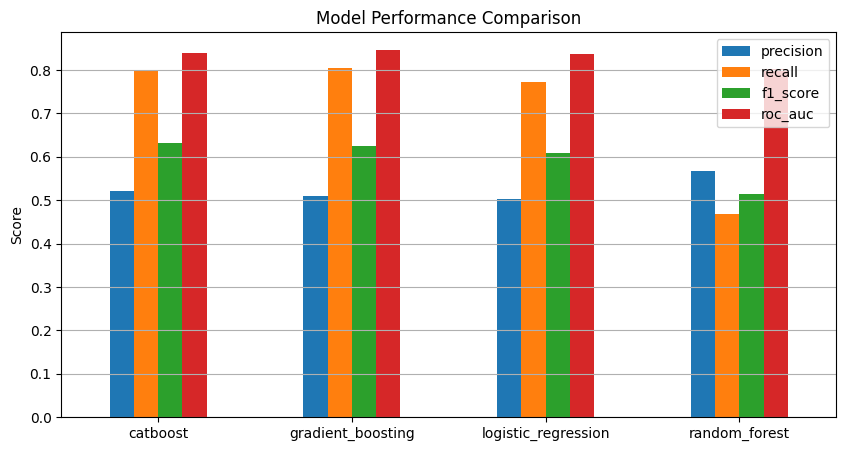

In [16]:
comparison_df[["precision", "recall", "f1_score", "roc_auc"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

### Visual Comparison Insights

The bar chart highlights trade-offs between precision, recall, F1-score, and
ROC-AUC across models:

- **Boosting-based models** (Gradient Boosting and CatBoost) consistently dominate
  in ROC-AUC and recall, confirming their superiority in ranking and detection
  of churners.
- **Random Forest** favors precision at the expense of recall, which is 
  suboptimal for churn prevention scenarios where missing a churner is more
  costly than a false alarm.
- **Logistic Regression** performs surprisingly well given its simplicity, reinforcing its usefulness
  as a benchmark model.

This visualization reinforces that Gradient Boosting offers the best balance
between overall discrimination and churn detection effectiveness.


## Feature Importance Analysis

### Logistic Regression

In [24]:
lr_model = joblib.load(
    MODELS_DIR / "logistic_regression" / "baseline.joblib"
)

lr_importance = pd.Series(
    lr_model.coef_[0],
    index=feature_names,
).sort_values(key=np.abs, ascending=False)

lr_importance.head(10)

tenure                           -0.766524
is_month_to_month                 0.451862
InternetService_Fiber optic       0.447260
InternetService_No               -0.398768
num_active_services               0.295543
OnlineSecurity_Yes               -0.267546
TechSupport_Yes                  -0.234951
PaymentMethod_Electronic check    0.178058
PaperlessBilling                  0.177883
Dependents                       -0.114450
dtype: float64

#### Insights

Logistic Regression highlights clear, directional drivers of churn:

- **tenure** is the most helpful differentiator between churners and non-churners,
  the more the customer is with us the less likely they are to churn.
- **is_month_to_month** shows the strongest positive association with
  churn, indicating higher churn risk among month-to-month customers.
- **PaymentMethod_Electronic check** and **PaperlessBilling** are positively
  associated with churn, suggesting payment convenience alone does not imply
  retention.
- **OnlineSecurity_Yes** and **TechSupport_Yes** have strong negative coefficients,
  confirming that support-related services reduce churn risk.

Overall, Logistic Regression provides strong interpretability and confirms known
business drivers of customer churn.

### Random Forest

In [25]:
rf_model = joblib.load(
    MODELS_DIR / "random_forest" / "baseline.joblib"
)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

rf_importance.head(10)

MonthlyCharges                    0.295366
tenure                            0.269792
is_month_to_month                 0.109633
num_active_services               0.061302
InternetService_Fiber optic       0.053372
PaymentMethod_Electronic check    0.034865
InternetService_No                0.028130
PaperlessBilling                  0.027960
OnlineSecurity_Yes                0.027760
TechSupport_Yes                   0.024419
dtype: float64

#### Insights

Random Forest captures non-linear and interaction-based importance:

- **MonthlyCharges** and **Tenure** emerge as dominant drivers, emphasizing the
  combined effect of customer lifetime and billing amount.
- **is_month_to_month** remains a strong indicator of churn.
- **Number of active services** contributes meaningfully, suggesting bundled
  customers are more stable.
- Support-related features (**OnlineSecurity**, **TechSupport**) retain importance
  but are less dominant than in linear models.

Random Forest emphasizes usage intensity and customer value rather than explicit
directional effects.

### Gradient Boosting

In [26]:
gb_model = joblib.load(
    MODELS_DIR / "gradient_boosting" / "gradient_boosting_tuned.joblib"
)

gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

gb_importance.head(10)

is_month_to_month                 0.475145
tenure                            0.172609
InternetService_Fiber optic       0.120854
MonthlyCharges                    0.061578
PaymentMethod_Electronic check    0.058145
InternetService_No                0.046165
OnlineSecurity_Yes                0.021946
PaperlessBilling                  0.021255
TechSupport_Yes                   0.007659
num_active_services               0.005634
dtype: float64

#### Insights

Gradient Boosting identifies a focused and stable set of churn drivers:

- **Tenure** is highly predictive of churn, indicating churn risk decreases
  significantly as customers stay longer.
- **Is_month_to_month** contracts are the highest predictors of churn, aligning with
  expectations of higher volatility.
- **InternetService_Fiber optic** remains a key churn driver across models.
- **MonthlyCharges** reinforces the importance of pricingand customer engagement.
- Support and payment-related features have less contribution.

Gradient Boosting prioritizes core structural churn drivers with high consistency.


## Cross-Model Feature Importance Comparison

In [29]:
importance_df = pd.DataFrame({
    "Logistic Regression": lr_importance,
    "Random Forest": rf_importance,
    "Gradient Boosting": gb_importance,
}).fillna(0)

importance_df.abs().mean(axis=1).sort_values(ascending=False).head(10)

tenure                            0.402975
is_month_to_month                 0.345547
InternetService_Fiber optic       0.207162
InternetService_No                0.157687
MonthlyCharges                    0.121398
num_active_services               0.120826
OnlineSecurity_Yes                0.105750
PaymentMethod_Electronic check    0.090356
TechSupport_Yes                   0.089010
PaperlessBilling                  0.075699
dtype: float64

### Insights

Across Logistic Regression, Random Forest, and Gradient Boosting, several features
consistently appear as key churn drivers:

- **Tenure** and **is_month_to_month* are the most stable and dominant features across models.
- **InternetService type (Fiber optic / No)** consistently influences churn risk.
- **MonthlyCharges** remains important in all models, linking pricing to churn.
- **Support-related services** (OnlineSecurity, TechSupport) repeatedly show
  protective effects.

The consistency of these features across model families strengthens confidence
in their business relevance and reliability.


## Key Insights

- Models that prioritize recall perform better for the churn prediction task,
  aligning with the business objective of identifying as many at-risk customers
  as possible.
- Gradient Boosting achieves the best overall balance between discrimination
  (ROC-AUC) and churn detection (recall), making it the strongest candidate.
- CatBoost performs competitively, offering slightly higher precision at the
  cost of marginally lower recall, and remains a viable alternative depending
  on business trade-offs.
- Logistic Regression demonstrates robust performance despite its simplicity,
  providing strong interpretability and confirming known churn drivers.
- Random Forest underperforms in recall, indicating it misses a large proportion
  of churners and is therefore less suitable for churn prevention scenarios.

Across all models, tenure and contract flexibility consistently dominate churn
prediction, reinforcing their role as core structural drivers rather than
model-specific artifacts.

## Conclusion

This analysis shows strong alignment between model performance metrics and
feature importance insights. `Gradient Boosting` emerges as the most reliable
model, achieving the highest ROC-AUC and recall while relying on a stable and
interpretable set of features.

Key churn drivers such as **tenure**, **month-to-month contracts**, **pricing**, and
**support-related services** appear consistently across model families, validating
the robustness of the approved feature set.

Logistic Regression serves as a strong and interpretable baseline, while
CatBoost remains a competitive alternative. Random Forest, despite high
precision, is less effective due to its low recall for churners.

Overall, the results are realistic, business-aligned, and suitable for
production-level churn prediction.


## Next Steps

- Select Gradient Boosting as the primary model for explainability and deployment
- Generate SHAP explanations to quantify individual feature contributions
- Translate key churn drivers into actionable business recommendations
- Integrate the selected model into the modular training and prediction pipeline
- Build dashboards and automated reports to support stakeholder decision-making
